In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import numpy as np
import os


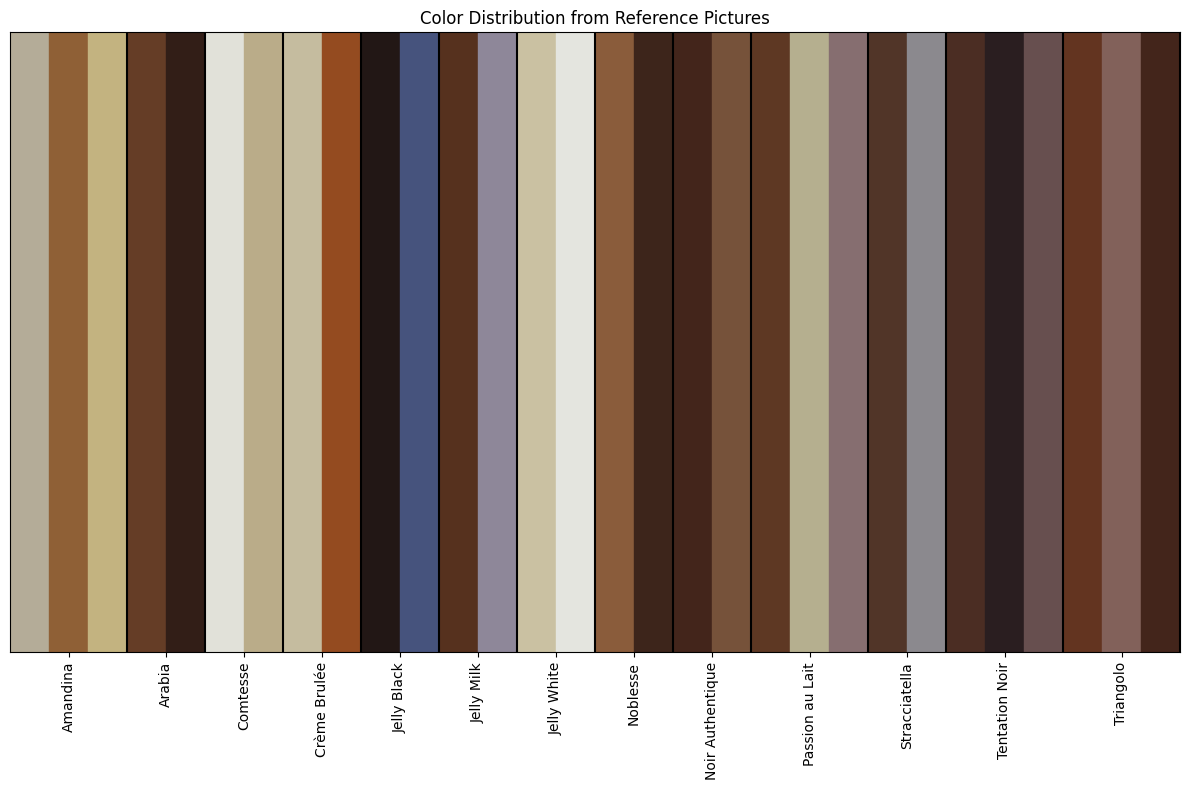

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dictionary of color data (RGB without alpha)
color_data = {
    "Amandina": [(180, 172, 152), (143, 96, 54), (195, 179, 128)],
    "Arabia": [(101, 61, 38), (50, 30, 23)],
    "Comtesse": [(225, 225, 217), (186, 172, 137)],
    "Crème Brulée": [(197, 188, 159), (148, 75, 32)],
    "Jelly Black": [(34, 23, 21), (70, 83, 125)],
    "Jelly Milk": [(86, 49, 30), (142, 135, 153)],
    "Jelly White": [(202, 193, 162), (228, 229, 223)],
    "Noblesse": [(138, 92, 59), (61, 37, 27)],
    "Noir Authentique": [(67, 37, 27), (118, 82, 58)],
    "Passion au Lait": [(94, 56, 35), (181, 175, 143), (134, 110, 112)],
    "Stracciatella": [(81, 53, 40), (139, 137, 142)],
    "Tentation Noir": [(75, 45, 35), (42, 30, 32), (103, 79, 79)],
    "Triangolo": [(99, 52, 32), (130, 97, 90), (67, 37, 27)],
}

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
x = 0
yticks = []
ylabels = []

for name, colors in color_data.items():
    for color in colors:
        # Normalize RGB values to [0,1] for matplotlib
        rgb_norm = tuple([c / 255 for c in color])
        ax.add_patch(mpatches.Rectangle((x, 0), 1, 1, color=rgb_norm))
        x += 1
    # Add a vertical line after each group of colors
    ax.axvline(x=x, color='black', linewidth=1.5, linestyle='-')
    yticks.append((x - len(colors) / 2))
    ylabels.append(name)

# Configure plot
ax.set_xlim(0, x)
ax.set_ylim(0, 1)
ax.set_xticks(yticks)
ax.set_xticklabels(ylabels, rotation=90)
ax.set_yticks([])
ax.set_title("Color Distribution from Reference Pictures")

plt.tight_layout()
plt.show()

In [23]:
# Function to convert RGB to HSV
def rgb_to_hsv(rgb):
    color = np.uint8([[rgb]])  # Create a single pixel image
    hsv = cv2.cvtColor(color, cv2.COLOR_RGB2HSV)
    return hsv[0][0]

In [70]:
# Function to create a combined mask
def create_combined_mask(image_bgr, color_data, tolerance=(5, 40, 30), kernel_fill=20, kernel_open=20):
    hsv_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    combined_mask = np.zeros(hsv_image.shape[:2], dtype=np.uint8)

    for reference_name, rgb_colors in color_data.items():
        for rgb in rgb_colors:
            hsv = rgb_to_hsv(rgb)
            lower = np.array([
                max(hsv[0] - tolerance[0], 0),
                max(hsv[1] - tolerance[1], 0),
                max(hsv[2] - tolerance[2], 0)
            ], dtype=np.uint8)  # Explicitly cast to uint8
            upper = np.array([
                min(hsv[0] + tolerance[0], 179),
                min(hsv[1] + tolerance[1], 255),
                min(hsv[2] + tolerance[2], 255)
            ], dtype=np.uint8)  # Explicitly cast to uint8
            mask = cv2.inRange(hsv_image, lower, upper)
            combined_mask = cv2.bitwise_or(combined_mask, mask)

    # Apply morphological operations
    # kernel = np.ones((kernel_size, kernel_size), np.uint8)
    kernel_fill = np.ones((kernel_fill, kernel_fill), np.uint8)
    kernel_open = np.ones((kernel_open, kernel_open), np.uint8)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel_fill)  # Fill small holes
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel_open)   # Remove noise


    return combined_mask

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# Function to convert RGB to HSV
def rgb_to_hsv(rgb):
    color = np.uint8([[rgb]])  # Create a single pixel image
    hsv = cv2.cvtColor(color, cv2.COLOR_RGB2HSV)
    return hsv[0][0]

# # Function to create a combined mask
# def create_combined_mask(image_bgr, color_data, tolerance=(10, 40, 40)):
#     hsv_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
#     combined_mask = np.zeros(hsv_image.shape[:2], dtype=np.uint8)

#     for reference_name, rgb_colors in color_data.items():
#         for rgb in rgb_colors:
#             hsv = rgb_to_hsv(rgb)
#             lower = np.array([
#                 max(hsv[0] - tolerance[0], 0),
#                 max(hsv[1] - tolerance[1], 0),
#                 max(hsv[2] - tolerance[2], 0)
#             ], dtype=np.uint8)  # Explicitly cast to uint8
#             upper = np.array([
#                 min(hsv[0] + tolerance[0], 179),
#                 min(hsv[1] + tolerance[1], 255),
#                 min(hsv[2] + tolerance[2], 255)
#             ], dtype=np.uint8)  # Explicitly cast to uint8
#             mask = cv2.inRange(hsv_image, lower, upper)
#             combined_mask = cv2.bitwise_or(combined_mask, mask)

#     return combined_mask

# Dictionary of color data (RGB without alpha)
color_data = {
    "Amandina": [(180, 172, 152), (143, 96, 54), (195, 179, 128)],
    "Arabia": [(101, 61, 38), (50, 30, 23)],
    "Comtesse": [(225, 225, 217), (186, 172, 137)],
    "Crème Brulée": [(197, 188, 159), (148, 75, 32)],
    "Jelly Black": [(34, 23, 21), (70, 83, 125)],
    "Jelly Milk": [(86, 49, 30), (142, 135, 153)],
    "Jelly White": [(202, 193, 162), (228, 229, 223)],
    "Noblesse": [(138, 92, 59), (61, 37, 27)],
    "Noir Authentique": [(67, 37, 27), (118, 82, 58)],
    "Passion au Lait": [(94, 56, 35), (181, 175, 143), (134, 110, 112)],
    "Stracciatella": [(81, 53, 40), (139, 137, 142)],
    "Tentation Noir": [(75, 45, 35), (42, 30, 32), (103, 79, 79)],
    "Triangolo": [(99, 52, 32), (130, 97, 90), (67, 37, 27)],
}

# Ensure the output folder exists
output_folder = "../dataset_project_iapr2025/train_preprocessed"
os.makedirs(output_folder, exist_ok=True)

# Example usage
dataset_path = "../dataset_project_iapr2025/train"
replacement_color = (183, 181, 184)  # RGB color to replace masked-out areas

for filename in os.listdir(dataset_path):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(dataset_path, filename)
        image = cv2.imread(image_path)

        # Create the combined mask
        combined_mask = create_combined_mask(image, color_data)

        # Create a copy of the image to modify
        result = image.copy()

        # Replace masked-out areas with the replacement color
        result[np.where(combined_mask == 0)] = replacement_color

        # Save the processed image to the output folder
        output_path = os.path.join(output_folder, filename)
        cv2.imwrite(output_path, result)

        # Convert images to RGB for matplotlib
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

        # Display the original image, combined mask, and result
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(image_rgb)
        plt.title(f"Original Image: {filename}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(combined_mask, cmap="gray")
        plt.title("Combined Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(result_rgb)
        plt.title("Result with Replacement Color")
        plt.axis("off")

        plt.tight_layout()
        plt.show()